In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch
from matplotlib import pyplot as plt
import tqdm

In [2]:
A_space = fd.fhrr_space(10000)
B_space = fd.fhrr_space(10000)
E_space = fd.fhrr_space(10000)
AE_map = fd.block_learning_map(A_space, E_space, 10000, (1, 1), learn_rate=0.00001, decay_rate=0.00001)
BE_map = fd.block_learning_map(B_space, E_space, 10000, (1, 1), learn_rate=0.00001, decay_rate=0.00001)

In [3]:
A_R = A_space.init_random_vec()
A_G = A_space.init_random_vec()
A_B = A_space.init_random_vec()
B_R = B_space.init_random_vec()
B_G = B_space.init_random_vec()
B_B = B_space.init_random_vec()
A_vecs = [A_R, A_G, A_B]
B_vecs = [B_R, B_G, B_B]

In [4]:
def ball_game(p, n):
    p = p[:]
    event_outcomes = []
    for i in range(n):
        outcome = np.random.choice(len(p), p=np.array(p)/np.sum(p))
        event_outcomes.append(outcome)
        p[outcome] -= 1
    return event_outcomes

In [5]:
def query(query_space, answer_space, event_space, QE_map, AE_map, query_vector, answer_vectors):
    answer_matrix = torch.concat(answer_vectors, axis=1)
    event_vector = QE_map.forwards(query_vector, normalize = True)
    answer_vector = AE_map.backwards(event_vector)
    pdf = answer_space.get_pdf(answer_vector, answer_matrix)
    return pdf
def query2(query_space, answer_space, event_space, QE_map, AE_map, query_vector, answer_vectors):
    answer_matrix = torch.concat(answer_vectors, axis=1)
    event_vector = QE_map.forwards(query_vector, normalize = False)
    answer_vector = AE_map.backwards(event_vector)
    pdf = answer_space.get_pdf(answer_vector, answer_matrix)
    return pdf

In [6]:
def recall(answer_space, event_space, AE_map, event_vector, answer_vectors):
    answer_matrix = torch.concat(answer_vectors, axis=1)
    answer_vector = AE_map.backwards(event_vector)
    pdf = answer_space.get_pdf(answer_vector, answer_matrix)
    return pdf

In [ ]:
p_dist = [0.2, 0.5, 0.3]
num_trials = 10000
dist_history = []
for trial in tqdm.tqdm(range(num_trials)):
    A_event = A_R
    B_event = B_vecs[np.random.choice(len(p_dist), p=np.array(p_dist)/np.sum(p_dist))]
    trial_event_vector = E_space.init_random_vec()
    AE_map.learn(A_event, trial_event_vector)
    BE_map.learn(B_event, trial_event_vector)
    dist = np.array(query(A_space, B_space, E_space, AE_map, BE_map, A_event, B_vecs)).flatten()
    dist_history.append(dist)
    


  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_11001/4095842242.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dist = np.array(query(A_space, B_space, E_space, AE_map, BE_map, A_event, B_vecs)).flatten()
100%|██████████| 10000/10000 [00:19<00:00, 502.46it/s]


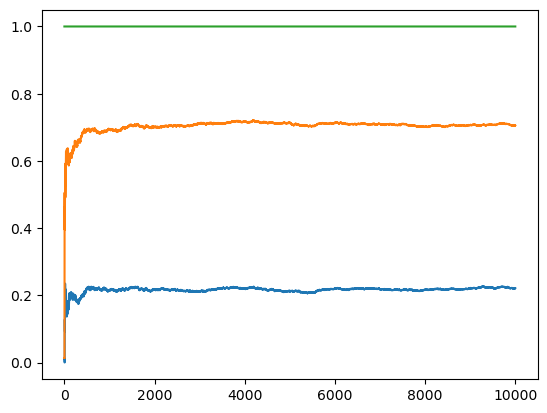

In [8]:
r_line = [dh[0] for dh in dist_history]
g_line = [dh[0] + dh[1] for dh in dist_history]
b_line = [dh[0] + dh[1] + dh[2] for dh in dist_history]
plt.plot(r_line)
plt.plot(g_line)
plt.plot(b_line)
plt.show()